# Peach Fuzz tuning

Score `peach_fuzz` on `data/search_queries.csv`. The router is not involved: every query is treated as a description query.

The description path has four knobs, and they interact.

- `alpha` weights the semantic score in the fused score: `alpha * semantic + (1 - alpha) * bm25`.
- `semantic_floor` is the minimum cosine similarity for an item to enter the candidate set. BM25 is then divided by the maximum BM25 inside that set, so the floor changes the lexical scores, not just who is eligible.
- `top_k` keeps that many candidates, in fused-score order.
- The fused-score cutoff drops anything below it. `handle_description` does this today at 0.5. It sits outside `peach_fuzz`, and it decides what the user sees, so it is part of the same search.

The previous notebook picked `alpha`, `semantic_floor`, and `top_k` at a cutoff of 0.5, then drew cutoff curves only at those winners. A floor that looks worse at 0.5 can be the better one at another cutoff, because that floor rebuilt the BM25 scale. This notebook scores the cross product and picks one configuration from it.

Recall comes first. A missed item is in the catalog and the user never sees it. Precision still matters: extra rows are noise. Latency matters because a person waits on this lookup, including when they search a list of items.

Three encoders run on the same grid. `all-MiniLM-L6-v2` is the one the pipeline uses now. `mixedbread-ai/mxbai-embed-xsmall-v1` and `BAAI/bge-small-en-v1.5` are here to show how much recall and precision move, and what that costs in query time.


In [1]:
import os
import sys
import time
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from rank_bm25 import BM25Okapi

%matplotlib inline

plt.rcParams.update({
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": 110,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
})

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")
DATA_DIR = Path(os.environ.get("DATA_DIR", ROOT / "data"))

items = duckdb.sql(
    f"SELECT * FROM read_csv_auto('{DATA_DIR}/gold/dim_item.csv')"
).df()
queries = pd.read_csv(DATA_DIR / "search_queries.csv")
print(f"{len(queries)} queries, {len(items)} items")


40 queries, 358 items


## Metrics

Same definitions as `evals.py`. Each query has equal weight. Precision is the share of returned items that were expected. Recall is the share of expected items that came back. F1 is the mean of the per-query F1 scores. MRR and MAP skip queries with an empty expected set, because there is no relevant item to rank.

An empty expected set is a no-match query. Returning nothing scores precision 1 and recall 1. Returning anything scores precision 0. Recall stays 1 in that branch, which is how `evals.py` defines it, so on no-match queries precision is the number that moves.


In [2]:
def expected_ids(value):
    if value is None or (isinstance(value, float) and np.isnan(value)):
        return []
    text = str(value).strip()
    if not text or text.lower() == "nan":
        return []
    return [part.strip() for part in text.split("|") if part.strip()]


def query_scores(retrieved, expected):
    expected_set = set(expected)
    hits = sum(item_id in expected_set for item_id in retrieved)
    if not retrieved and not expected:
        precision, recall = 1.0, 1.0
    elif not retrieved:
        precision, recall = 0.0, 0.0
    else:
        precision = hits / len(retrieved)
        recall = hits / len(expected) if expected else 1.0
    f1 = (
        2 * precision * recall / (precision + recall) if precision + recall else 0.0
    )

    reciprocal_rank = None
    average_precision = None
    if expected:
        reciprocal_rank = 0.0
        hit_count = 0
        precision_sum = 0.0
        for rank, item_id in enumerate(retrieved, start=1):
            if item_id in expected_set:
                if reciprocal_rank == 0.0:
                    reciprocal_rank = 1.0 / rank
                hit_count += 1
                precision_sum += hit_count / rank
        average_precision = precision_sum / len(expected)
    return precision, recall, f1, reciprocal_rank, average_precision


query_texts = queries["query"].astype(str).tolist()
query_types = queries["query_type"].astype(str).tolist()
expected_lists = [expected_ids(value) for value in queries["expected_item_ids"]]
item_ids = items["item_id"].astype(str).tolist()
texts = items["search_text"].fillna("").astype(str).tolist()

sizes = [len(expected) for expected in expected_lists]
biggest = int(np.argmax(sizes))
print(
    f"Largest expected set is {sizes[biggest]} "
    f"({query_texts[biggest]!r}, {query_types[biggest]})."
)
print(queries["query_type"].value_counts().to_string())


Largest expected set is 7 ('coupling set screw', partial).
query_type
abbreviation    8
misspelled      8
exact           8
partial         8
no_match        4
word_order      4


## Encoders

Catalog embeddings are built once per model. The grid reuses them. Latency is measured separately, one query at a time, because that is the path `peach_fuzz` runs when a person is waiting.

`all-MiniLM-L6-v2` is symmetric: the query and the catalog text are embedded as written. BGE-small and mxbai-xsmall are trained asymmetrically. The query gets the prefix stored on the model (the usual retrieval instruction); catalog text is embedded without it. That prefix is part of using those models, and the latency number includes it.

BM25 does not depend on the encoder, so it is fit once, on the same tokens `peach_fuzz` uses.


In [3]:
import logging

from sentence_transformers import SentenceTransformer

from src.item_search.peach_fuzz import peach_fuzz
from src.item_search.utils import tokenize

logging.getLogger("sentence_transformers").setLevel(logging.ERROR)

MODELS = [
    ("MiniLM", "all-MiniLM-L6-v2"),
    ("mxbai-xsmall", "mixedbread-ai/mxbai-embed-xsmall-v1"),
    ("BGE-small", "BAAI/bge-small-en-v1.5"),
]
MODEL_ORDER = [label for label, _ in MODELS]
COLORS = {
    "MiniLM": "#4C78A8",
    "mxbai-xsmall": "#54A24B",
    "BGE-small": "#F58518",
}
RETRIEVAL_PROMPT = "Represent this sentence for searching relevant passages: "

bm25_index = BM25Okapi([tokenize(text) for text in texts])
bm25_matrix = np.vstack(
    [np.asarray(bm25_index.get_scores(tokenize(query)), dtype=float) for query in query_texts]
)


def retrieval_prompt(model, model_name):
    prompts = dict(model.prompts or {})
    if prompts.get("query"):
        return prompts["query"]
    if "minilm" in model_name.lower():
        return ""
    return RETRIEVAL_PROMPT


def embed(model, sentences, prompt):
    return np.asarray(
        model.encode(
            sentences,
            prompt=prompt if prompt else "",
            normalize_embeddings=True,
            show_progress_bar=False,
            convert_to_numpy=True,
        )
    )


def measure_latency(model, prompt, embeddings):
    # Fixed knobs: latency is the encode, not the grid. Warm up, then time every query.
    # Sync so an async device does not return before the encode has finished.
    import torch

    def sync():
        if torch.backends.mps.is_available():
            torch.mps.synchronize()
        elif torch.cuda.is_available():
            torch.cuda.synchronize()

    def once(query):
        sync()
        started = time.perf_counter()
        qvec = embed(model, [query], prompt)[0]
        sem = np.clip(embeddings @ qvec, 0, 1)
        candidates = np.flatnonzero(sem >= 0.40)
        if len(candidates):
            raw = np.asarray(bm25_index.get_scores(tokenize(query)), dtype=float)
            bm = raw[candidates]
            peak = float(bm.max())
            bm_norm = bm / peak if peak > 0 else bm
            fused = 0.5 * sem[candidates] + 0.5 * bm_norm
            np.argsort(-fused)[:10]
        sync()
        return (time.perf_counter() - started) * 1000

    for query in query_texts[:3]:
        once(query)
    samples = np.array([once(query) for query in query_texts])
    order = np.argsort(-samples)[:3]
    slowest = ", ".join(f"{query_texts[i]!r} {samples[i]:.0f} ms" for i in order)
    return {
        "latency_median_ms": float(np.median(samples)),
        "latency_mean_ms": float(samples.mean()),
        "latency_p95_ms": float(np.percentile(samples, 95)),
        "slowest": slowest,
    }


encoders = {}
for label, model_name in MODELS:
    started = time.perf_counter()
    model = SentenceTransformer(model_name)
    prompt = retrieval_prompt(model, model_name)
    embeddings = embed(model, texts, prompt="")
    query_matrix = embed(model, query_texts, prompt)
    sem = np.clip(query_matrix @ embeddings.T, 0, 1)
    latency = measure_latency(model, prompt, embeddings)
    slowest = latency.pop("slowest")
    encoders[label] = {
        "model_name": model_name,
        "model": model,
        "prompt": prompt,
        "embeddings": embeddings,
        "sem": sem,
        **latency,
    }
    print(
        f"{label}  {model_name}  dim={embeddings.shape[1]}  device={model.device}\n"
        f"  query prompt={prompt!r}\n"
        f"  latency {latency['latency_median_ms']:.1f} ms median, "
        f"{latency['latency_mean_ms']:.1f} ms mean, "
        f"{latency['latency_p95_ms']:.1f} ms p95  "
        f"(loaded in {time.perf_counter() - started:.0f}s)\n"
        f"  slowest: {slowest}"
    )


MiniLM  all-MiniLM-L6-v2  dim=384  device=mps:0
  query prompt=''
  latency 32.8 ms median, 62.3 ms mean, 151.1 ms p95  (loaded in 9s)
  slowest: 'coupling set screw' 197 ms, 'electrical metallic tubing 2" x 10\'' 167 ms, "uf-b underground feeder cable 14/2 250'" 150 ms


mxbai-xsmall  mixedbread-ai/mxbai-embed-xsmall-v1  dim=384  device=mps:0
  query prompt='Represent this sentence for searching relevant passages: '
  latency 32.1 ms median, 57.7 ms mean, 164.3 ms p95  (loaded in 6s)
  slowest: 'condnit strap 1-1/4in emt 1 hole' 181 ms, 'electrical metallic tubing 2" x 10\'' 170 ms, 'mc cable 10/2 alumnium armor 250ft' 164 ms


BGE-small  BAAI/bge-small-en-v1.5  dim=384  device=mps:0
  query prompt='Represent this sentence for searching relevant passages: '
  latency 55.4 ms median, 58.7 ms mean, 62.5 ms p95  (loaded in 6s)
  slowest: 'rigid metal conduit 1in x 10ft' 173 ms, 'coupling set screw' 64 ms, '3/4in white' 62 ms


## The sweep uses the same math as `peach_fuzz`

`rank_query` is the body of `peach_fuzz`: clip the cosine at 0, drop items under the floor, rescale BM25 inside what remains, fuse, keep `top_k`. The cutoff is applied after that, which is what `handle_description` does with the fused score.

The check below runs both on the current default (`alpha=0.5`, floor `0.3`, `top_k=10`, cutoff `0.5`) and compares the item ids. MiniLM has no query prefix, so this is the production path.


In [4]:
def rank_query(sem_row, bm25_row, alpha, floor, top_k):
    candidates = np.flatnonzero(sem_row >= floor)
    if len(candidates) == 0:
        return [], np.array([])
    sem = sem_row[candidates]
    bm = bm25_row[candidates]
    peak = float(bm.max())
    # Rescale inside the candidate set. A higher floor changes these weights.
    bm_norm = bm / peak if peak > 0 else bm
    fused = alpha * sem + (1.0 - alpha) * bm_norm
    order = np.argsort(-fused)[:top_k]
    ids = [item_ids[int(candidates[j])] for j in order]
    return ids, fused[order]


def kept_ids(sem_row, bm25_row, alpha, floor, top_k, cutoff):
    ids, scores = rank_query(sem_row, bm25_row, alpha, floor, top_k)
    return [item_id for item_id, score in zip(ids, scores) if score >= cutoff]


mini = encoders["MiniLM"]
desc_index = {
    "item_ids": item_ids,
    "texts": texts,
    "bm25": bm25_index,
    "model": mini["model"],
    "embeddings": mini["embeddings"],
}

mismatches = []
cosine_gaps = []
for i, query in enumerate(query_texts):
    qvec = mini["model"].encode(
        [query], normalize_embeddings=True, show_progress_bar=False
    )[0]
    sem_row = np.clip(desc_index["embeddings"] @ qvec, 0, 1)
    cosine_gaps.append(float(np.max(np.abs(sem_row - mini["sem"][i]))))
    ids, scores = rank_query(sem_row, bm25_matrix[i], 0.5, 0.3, 10)
    pred = [item_id for item_id, score in zip(ids, scores) if score >= 0.5]
    produced = peach_fuzz(query, desc_index, alpha=0.5, semantic_floor=0.3, top_k=10)
    got = [row["item_id"] for row in produced if row["score"] >= 0.5]
    if got != pred:
        mismatches.append((query, got, pred))

print(f"max |one-query cosine − grid cosine| on MiniLM: {max(cosine_gaps):.2e}")
if mismatches:
    query, got, pred = mismatches[0]
    raise AssertionError(
        f"{len(mismatches)} mismatches. First query {query!r}: peach_fuzz={got}, sweep={pred}"
    )
print(f"peach_fuzz and the sweep agree on all {len(query_texts)} queries at the current default.")


max |one-query cosine − grid cosine| on MiniLM: 3.87e-07
peach_fuzz and the sweep agree on all 40 queries at the current default.


## Do the encoders separate the right item?

For each query that has an expected item, the vertical axis is the cosine of the best expected item and the horizontal axis is the cosine of the nearest item that was not expected. A point above the diagonal means some floor can keep that best item and drop the distractor. The vertical axis is the best expected item, not the weakest one: a partial query can still lose a secondary match, and recall is what records that.

No-match queries are not on the plot. The table is their maximum cosine, which is the score a floor has to sit above if those queries are going to come back empty.

The three panels share one scale, so a model whose mass sits higher up the diagonal is using a different cosine range. The floor grid below is wide enough to cover that.


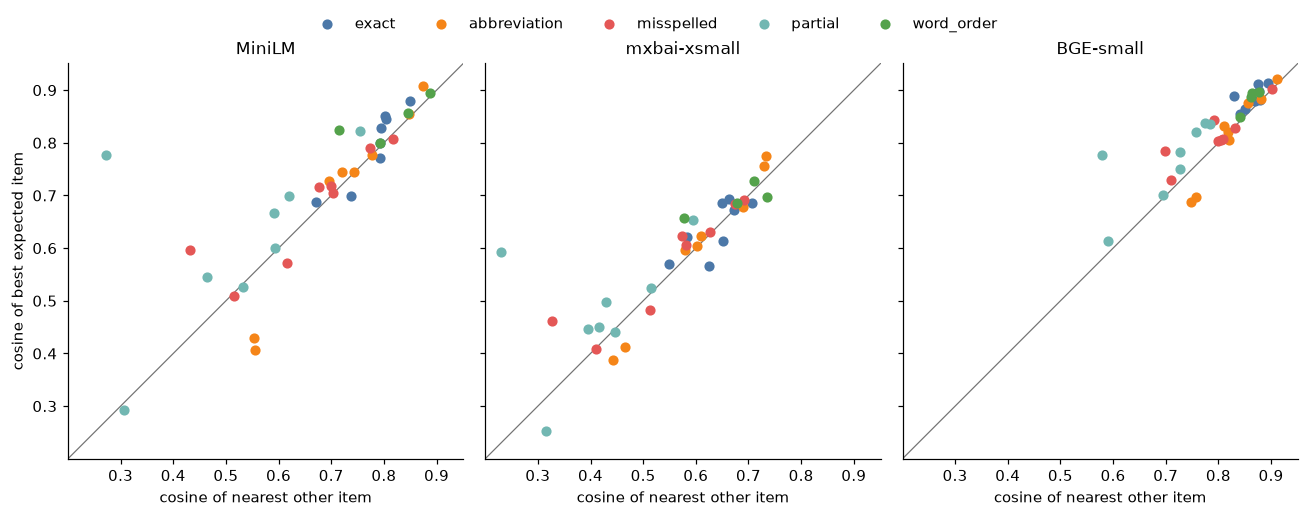

,model,median_best_expected,median_nearest_other,share_above_diagonal
0,MiniLM,0.744,0.717,0.750
1,mxbai-xsmall,0.618,0.588,0.639
2,BGE-small,0.837,0.819,0.833


Maximum cosine on no-match queries


,query,MiniLM,mxbai-xsmall,BGE-small
0,copper pipe 3/4 type l,0.507,0.421,0.677
1,drywall screws 1-5/8 coarse,0.315,0.350,0.655
2,pex tubing 1/2 red 100ft,0.447,0.353,0.687
3,hvac filter 20x25x1,0.329,0.305,0.650


In [5]:
item_index = {item_id: i for i, item_id in enumerate(item_ids)}


def separation_frame(sem):
    rows = []
    for query, query_type, expected, sem_row in zip(
        query_texts, query_types, expected_lists, sem
    ):
        if not expected:
            continue
        idxs = [item_index[item_id] for item_id in expected if item_id in item_index]
        if not idxs:
            continue
        mask = np.ones(sem_row.shape[0], dtype=bool)
        mask[idxs] = False
        rows.append({
            "query": query,
            "query_type": query_type,
            "relevant": float(sem_row[idxs].max()),
            "distractor": float(sem_row[mask].max()),
        })
    return pd.DataFrame(rows)


QUERY_COLORS = {
    "exact": "#4C78A8",
    "abbreviation": "#F58518",
    "misspelled": "#E45756",
    "partial": "#72B7B2",
    "word_order": "#54A24B",
}

frames = {label: separation_frame(encoders[label]["sem"]) for label in MODEL_ORDER}
stacked = np.concatenate(
    [np.concatenate([frame.relevant, frame.distractor]) for frame in frames.values()]
)
lo = float(stacked.min()) - 0.03
hi = float(stacked.max()) + 0.03

fig, axes = plt.subplots(1, 3, figsize=(12, 4.2), sharex=True, sharey=True)
for ax, label in zip(axes, MODEL_ORDER):
    frame = frames[label]
    for query_type in QUERY_COLORS:
        group = frame[frame.query_type == query_type]
        ax.scatter(
            group.distractor,
            group.relevant,
            s=32,
            color=QUERY_COLORS[query_type],
            label=query_type,
            zorder=3,
        )
    ax.plot([lo, hi], [lo, hi], color="0.45", lw=0.8, zorder=1)
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.set_aspect("equal", adjustable="box")
    ax.set_title(label)
    ax.set_xlabel("cosine of nearest other item")
axes[0].set_ylabel("cosine of best expected item")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=5, frameon=False, bbox_to_anchor=(0.5, 1.08))
fig.tight_layout()
plt.show()

sep_summary = []
for label, frame in frames.items():
    sep_summary.append({
        "model": label,
        "median_best_expected": frame.relevant.median(),
        "median_nearest_other": frame.distractor.median(),
        "share_above_diagonal": (frame.relevant > frame.distractor).mean(),
    })
display(pd.DataFrame(sep_summary).round(3))

no_match_rows = []
for query, expected, index in zip(query_texts, expected_lists, range(len(query_texts))):
    if expected:
        continue
    no_match_rows.append({
        "query": query,
        **{label: float(encoders[label]["sem"][index].max()) for label in MODEL_ORDER},
    })
print("Maximum cosine on no-match queries")
display(pd.DataFrame(no_match_rows).round(3))


## Decision rule

Missing the only expected item on one query drops macro recall by 1/40 = 0.025. The largest expected set in this file has 7 ids, so `top_k` of 1, 2, 3, or 5 cannot recall every labeled item on that query. `top_k` of 8, 10, and 15 can.

The highest-recall configuration is a long list. The floor and the cutoff are loose, `top_k` is at the top of the grid, and most of the rows are not the expected item. Recall was bought by showing extra items. A result list that returns eight near-misses so it does not miss one row is a noisy search.

The operating point keeps recall at or above 0.90 and, inside that band, takes the highest precision. 0.90 leaves room for about four single-item misses across the file. That is where the front stops spending a lot of precision on the last few points of recall. The table repeats the choice at 0.975, 0.95, 0.925, 0.90, 0.85, and 0.80, so the line can move if a tighter recall is worth the precision it costs.

`mean_results` is the average number of items returned: the length of the list a person scrolls.

Across encoders, take the operating point with the highest precision, then the highest recall. A faster encoder replaces it only when it is within 0.02 on both and at least 10 ms faster on the median. Query time barely moves inside one encoder, so latency is only that cross-encoder check.


In [6]:
ALPHAS = [0.0, 0.2, 0.3, 0.4, 0.5, 0.6, 0.8, 1.0]
FLOORS = [round(i / 100, 2) for i in range(5, 90, 5)]
TOP_KS = [1, 2, 3, 5, 8, 10, 15]
CUTOFFS = [0.0] + [round(i / 100, 2) for i in range(30, 90, 5)]

RECALL_FLOOR = 0.90
RECALL_FLOORS = [0.80, 0.85, 0.90, 0.925, 0.95, 0.975]
FASTER_MODEL_TOLERANCE = 0.02
FASTER_MODEL_MS = 10.0

# Today's description path: peach_fuzz defaults, then handle_description at 0.5.
CURRENT = {
    "model": "MiniLM",
    "alpha": 0.5,
    "semantic_floor": 0.30,
    "top_k": 10,
    "cutoff": 0.50,
}

SHOW_COLS = [
    "model", "alpha", "semantic_floor", "top_k", "cutoff",
    "recall", "precision", "mean_results", "f1", "mrr",
    "latency_median_ms", "latency_p95_ms",
]
ROUNDING = {
    "alpha": 2, "semantic_floor": 2, "cutoff": 2,
    "recall": 4, "precision": 4, "mean_results": 2, "f1": 4, "mrr": 4,
    "average_precision": 4,
    "latency_median_ms": 1, "latency_mean_ms": 1, "latency_p95_ms": 1,
    "recall_drop": 4, "precision_gain": 4, "recall_floor": 3,
}


def show_table(frame):
    formatted = frame.copy()
    if "top_k" in formatted.columns:
        formatted["top_k"] = formatted["top_k"].astype(int)
    for col, digits in ROUNDING.items():
        if col in formatted.columns:
            formatted[col] = formatted[col].map(lambda value: round(float(value), digits))
    display(formatted.reset_index(drop=True))


def aggregate(truncated, cutoff):
    precision_sum = recall_sum = f1_sum = 0.0
    n_returned = 0
    rr_values = []
    ap_values = []
    for (ids, scores), expected in zip(truncated, expected_lists):
        kept = [item_id for item_id, score in zip(ids, scores) if score >= cutoff]
        precision, recall, f1, rr, ap = query_scores(kept, expected)
        precision_sum += precision
        recall_sum += recall
        f1_sum += f1
        n_returned += len(kept)
        if rr is not None:
            rr_values.append(rr)
            ap_values.append(ap)
    n = len(truncated)
    return {
        "recall": recall_sum / n,
        "precision": precision_sum / n,
        "mean_results": n_returned / n,
        "f1": f1_sum / n,
        "mrr": float(np.mean(rr_values)),
        "average_precision": float(np.mean(ap_values)),
    }


def sweep_model(label, sem):
    print(f"scoring {label}...", flush=True)
    rows = []
    latency_median_ms = encoders[label]["latency_median_ms"]
    latency_mean_ms = encoders[label]["latency_mean_ms"]
    latency_p95_ms = encoders[label]["latency_p95_ms"]
    for floor in FLOORS:
        packs = []
        for q in range(sem.shape[0]):
            candidates = np.flatnonzero(sem[q] >= floor)
            if len(candidates) == 0:
                packs.append(None)
                continue
            bm = bm25_matrix[q, candidates]
            peak = float(bm.max())
            bm_norm = bm / peak if peak > 0 else bm
            packs.append((candidates, sem[q, candidates], bm_norm))
        for alpha in ALPHAS:
            ranked = []
            for pack in packs:
                if pack is None:
                    ranked.append(([], np.array([])))
                    continue
                candidates, sem_c, bm_norm = pack
                fused = alpha * sem_c + (1.0 - alpha) * bm_norm
                order = np.argsort(-fused)
                ranked.append((
                    [item_ids[int(candidates[j])] for j in order],
                    fused[order],
                ))
            for top_k in TOP_KS:
                truncated = [(ids[:top_k], scores[:top_k]) for ids, scores in ranked]
                for cutoff in CUTOFFS:
                    metrics = aggregate(truncated, cutoff)
                    rows.append({
                        "model": label,
                        "alpha": alpha,
                        "semantic_floor": floor,
                        "top_k": top_k,
                        "cutoff": cutoff,
                        "latency_median_ms": latency_median_ms,
                        "latency_mean_ms": latency_mean_ms,
                        "latency_p95_ms": latency_p95_ms,
                        **metrics,
                    })
    return pd.DataFrame(rows)


def highest_recall(frame):
    return frame.sort_values(
        ["recall", "precision", "mrr", "semantic_floor", "latency_median_ms"],
        ascending=[False, False, False, False, True],
    ).iloc[0]


def best_in_recall_band(frame, recall_floor):
    band = frame[frame["recall"] >= recall_floor - 1e-12]
    if band.empty:
        return None
    # A higher floor that leaves precision and recall unchanged is the same list
    # with a tighter gate, so it wins the tie.
    return band.sort_values(
        ["precision", "recall", "mrr", "semantic_floor", "latency_median_ms"],
        ascending=[False, False, False, False, True],
    ).iloc[0]


def choose_model(operating):
    leader = operating.sort_values(
        ["precision", "recall", "latency_median_ms"],
        ascending=[False, False, True],
    ).iloc[0]
    close = operating[
        (operating["precision"] >= leader["precision"] - FASTER_MODEL_TOLERANCE)
        & (operating["recall"] >= leader["recall"] - FASTER_MODEL_TOLERANCE)
        & (operating["latency_median_ms"] <= leader["latency_median_ms"] - FASTER_MODEL_MS)
    ]
    if close.empty:
        return leader, leader
    winner = close.sort_values(
        ["latency_median_ms", "precision", "recall"],
        ascending=[True, False, False],
    ).iloc[0]
    return leader, winner


def lookup_config(frame, spec):
    hit = frame[
        (frame["model"] == spec["model"])
        & np.isclose(frame["alpha"], spec["alpha"])
        & np.isclose(frame["semantic_floor"], spec["semantic_floor"])
        & (frame["top_k"] == spec["top_k"])
        & np.isclose(frame["cutoff"], spec["cutoff"])
    ]
    if len(hit) != 1:
        raise AssertionError(f"expected one row for {spec}, found {len(hit)}")
    return hit.iloc[0]


started = time.perf_counter()
grid = pd.concat([sweep_model(label, encoders[label]["sem"]) for label in MODEL_ORDER], ignore_index=True)
print(
    f"{len(grid)} configurations "
    f"({len(ALPHAS)} alphas × {len(FLOORS)} floors × {len(TOP_KS)} top_k × {len(CUTOFFS)} cutoffs × {len(MODEL_ORDER)} encoders) "
    f"in {time.perf_counter() - started:.1f}s"
)


scoring MiniLM...


scoring mxbai-xsmall...


scoring BGE-small...


37128 configurations (8 alphas × 17 floors × 7 top_k × 13 cutoffs × 3 encoders) in 6.0s


## The grid

Faint points are every configuration with recall of at least 0.80. The line is that encoder's Pareto front: nothing else is at least as good on both recall and precision and strictly better on one of them. Stars are the operating points, the best precision among configurations with recall of at least 0.90. Open circles are each encoder's highest-recall configuration. The shaded band is the 0.90 floor. The × is today's path: MiniLM, `alpha=0.5`, floor `0.30`, `top_k=10`, cutoff `0.50`.

The second figure is what that rule keeps if the floor moves. The dashed line is 0.90. `recall_drop` and `precision_gain` in the table are against that encoder's highest-recall configuration.


Operating points: best precision with recall >= 0.90


,model,alpha,semantic_floor,top_k,cutoff,recall,precision,mean_results,f1,mrr,latency_median_ms,latency_p95_ms
0,MiniLM,0.8,0.45,3,0.60,0.9045,0.5083,2.33,0.6056,0.8426,32.8,151.1
1,mxbai-xsmall,0.6,0.40,3,0.55,0.9045,0.4750,2.42,0.5723,0.8287,32.1,164.3
2,BGE-small,1.0,0.70,3,0.00,0.9045,0.5000,2.48,0.5973,0.8611,55.4,62.5


Best precision at each recall floor. recall_drop and precision_gain are against that model's highest-recall configuration.


,model,recall_floor,alpha,semantic_floor,top_k,cutoff,recall,precision,mean_results,recall_drop,precision_gain
0,MiniLM,0.800,0.3,0.45,3,0.85,0.8009,0.7042,1.43,0.1741,0.5084
1,MiniLM,0.850,0.0,0.20,8,0.85,0.8500,0.6175,2.20,0.1250,0.4217
2,MiniLM,0.900,0.8,0.45,3,0.60,0.9045,0.5083,2.33,0.0705,0.3126
3,MiniLM,0.925,0.6,0.25,3,0.55,0.9295,0.4208,2.70,0.0455,0.2251
4,MiniLM,0.950,0.5,0.25,8,0.60,0.9500,0.3399,4.72,0.0250,0.1441
5,MiniLM,0.975,0.6,0.25,15,0.45,0.9750,0.1958,9.70,0.0000,0.0000
6,mxbai-xsmall,0.800,0.2,0.40,3,0.85,0.8009,0.7042,1.40,0.1991,0.5977
7,mxbai-xsmall,0.850,0.0,0.20,8,0.85,0.8500,0.6175,2.23,0.1500,0.5111
8,mxbai-xsmall,0.900,0.6,0.40,3,0.55,0.9045,0.4750,2.42,0.0955,0.3686
9,mxbai-xsmall,0.925,0.6,0.40,3,0.45,0.9295,0.4625,2.55,0.0705,0.3561


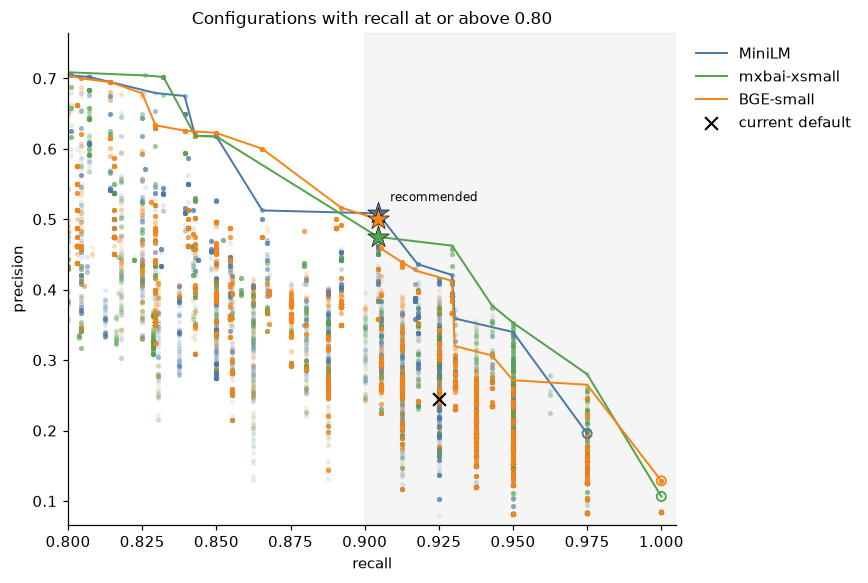

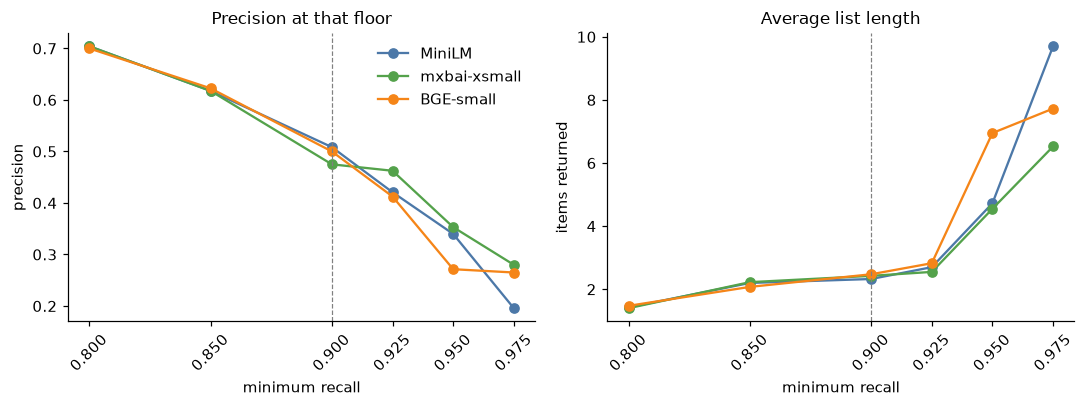

In [7]:
def pareto_front(frame):
    recall = frame["recall"].to_numpy()
    precision = frame["precision"].to_numpy()
    order = np.lexsort((-precision, -recall))
    keep = np.zeros(len(frame), dtype=bool)
    best_precision = -np.inf
    for position in order:
        if precision[position] > best_precision + 1e-12:
            keep[position] = True
            best_precision = precision[position]
    return frame.loc[keep].sort_values(["recall", "precision"], ascending=[False, False])


anchors = {label: highest_recall(grid[grid.model == label]) for label in MODEL_ORDER}
floor_rows = []
operating_rows = []
for label in MODEL_ORDER:
    subset = grid[grid.model == label]
    anchor = anchors[label]
    for recall_floor in RECALL_FLOORS:
        chosen = best_in_recall_band(subset, recall_floor)
        if chosen is None:
            continue
        record = chosen.to_dict()
        record["recall_floor"] = recall_floor
        record["recall_drop"] = float(anchor["recall"] - chosen["recall"])
        record["precision_gain"] = float(chosen["precision"] - anchor["precision"])
        floor_rows.append(record)
        if abs(recall_floor - RECALL_FLOOR) < 1e-12:
            operating_rows.append(record)

operating = pd.DataFrame(operating_rows)
floor_table = pd.DataFrame(floor_rows)
leader, recommended = choose_model(operating)
baseline = lookup_config(grid, CURRENT)
recommended_anchor = anchors[recommended["model"]]

print(f"Operating points: best precision with recall >= {RECALL_FLOOR:.2f}")
show_table(operating[SHOW_COLS])
print("Best precision at each recall floor. recall_drop and precision_gain are against that model's highest-recall configuration.")
show_table(floor_table[[
    "model", "recall_floor", "alpha", "semantic_floor", "top_k", "cutoff",
    "recall", "precision", "mean_results", "recall_drop", "precision_gain",
]])

fig, ax = plt.subplots(figsize=(8.0, 5.4))
fronts = {label: pareto_front(grid[grid.model == label]) for label in MODEL_ORDER}
front_focus = pd.concat(fronts.values())
front_focus = front_focus[front_focus["recall"] >= 0.80]
view = grid[grid["recall"] >= 0.80]
for label in MODEL_ORDER:
    cloud = view[view.model == label]
    front = fronts[label].sort_values("recall")
    ax.scatter(
        cloud.recall, cloud.precision,
        s=11, alpha=0.15, color=COLORS[label], linewidths=0, zorder=1,
    )
    ax.plot(front.recall, front.precision, color=COLORS[label], lw=1.3, label=label, zorder=2)
    anchor = anchors[label]
    ax.scatter(
        [anchor.recall], [anchor.precision],
        marker="o", s=36, facecolors="none", edgecolors=COLORS[label],
        linewidths=1.2, zorder=3,
    )
    point = operating[operating.model == label].iloc[0]
    ax.scatter(
        [point.recall], [point.precision],
        marker="*", s=220, color=COLORS[label],
        edgecolors="black", linewidths=0.4, zorder=4,
    )

ax.scatter(
    [baseline.recall], [baseline.precision],
    marker="x", s=70, color="black", linewidths=1.4, zorder=5, label="current default",
)
ax.axvspan(RECALL_FLOOR, 1.02, color="0.5", alpha=0.08, zorder=0)
ax.annotate(
    "recommended",
    (recommended.recall, recommended.precision),
    textcoords="offset points",
    xytext=(8, 8),
    fontsize=8,
)
ax.set_xlim(0.80, 1.005)
ax.set_ylim(
    max(0.0, float(front_focus["precision"].min()) - 0.04),
    min(1.02, float(front_focus["precision"].max()) + 0.06),
)
ax.set_xlabel("recall")
ax.set_ylabel("precision")
ax.set_title("Configurations with recall at or above 0.80")
ax.legend(frameon=False, loc="upper left", bbox_to_anchor=(1.01, 1))
fig.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8), sharex=True)
for label in MODEL_ORDER:
    curve = floor_table[floor_table.model == label].sort_values("recall_floor")
    axes[0].plot(curve.recall_floor, curve.precision, marker="o", color=COLORS[label], label=label)
    axes[1].plot(curve.recall_floor, curve.mean_results, marker="o", color=COLORS[label], label=label)
for axis, title, ylabel in zip(
    axes,
    ["Precision at that floor", "Average list length"],
    ["precision", "items returned"],
):
    axis.axvline(RECALL_FLOOR, color="0.5", lw=0.8, ls="--")
    axis.set_xlabel("minimum recall")
    axis.set_ylabel(ylabel)
    axis.set_title(title)
    axis.set_xticks(RECALL_FLOORS)
    axis.tick_params(axis="x", labelrotation=45)
axes[0].legend(frameon=False)
fig.tight_layout()
plt.show()


## Floor × cutoff, at the chosen alpha and top_k

Each row is one encoder, sliced at that encoder's operating `alpha` and `top_k`. These two axes are the pair the previous notebook could not see at the same time: the floor rebuilds the BM25 scale, and the cutoff is applied to the fused score that comes out of it. The ring is the operating floor and cutoff. A brighter cell is higher. Recall color runs from 0.5 to 1, shared down the column, so the band we actually choose from is where the color moves. Precision color runs from 0 to the best cell in the figure.


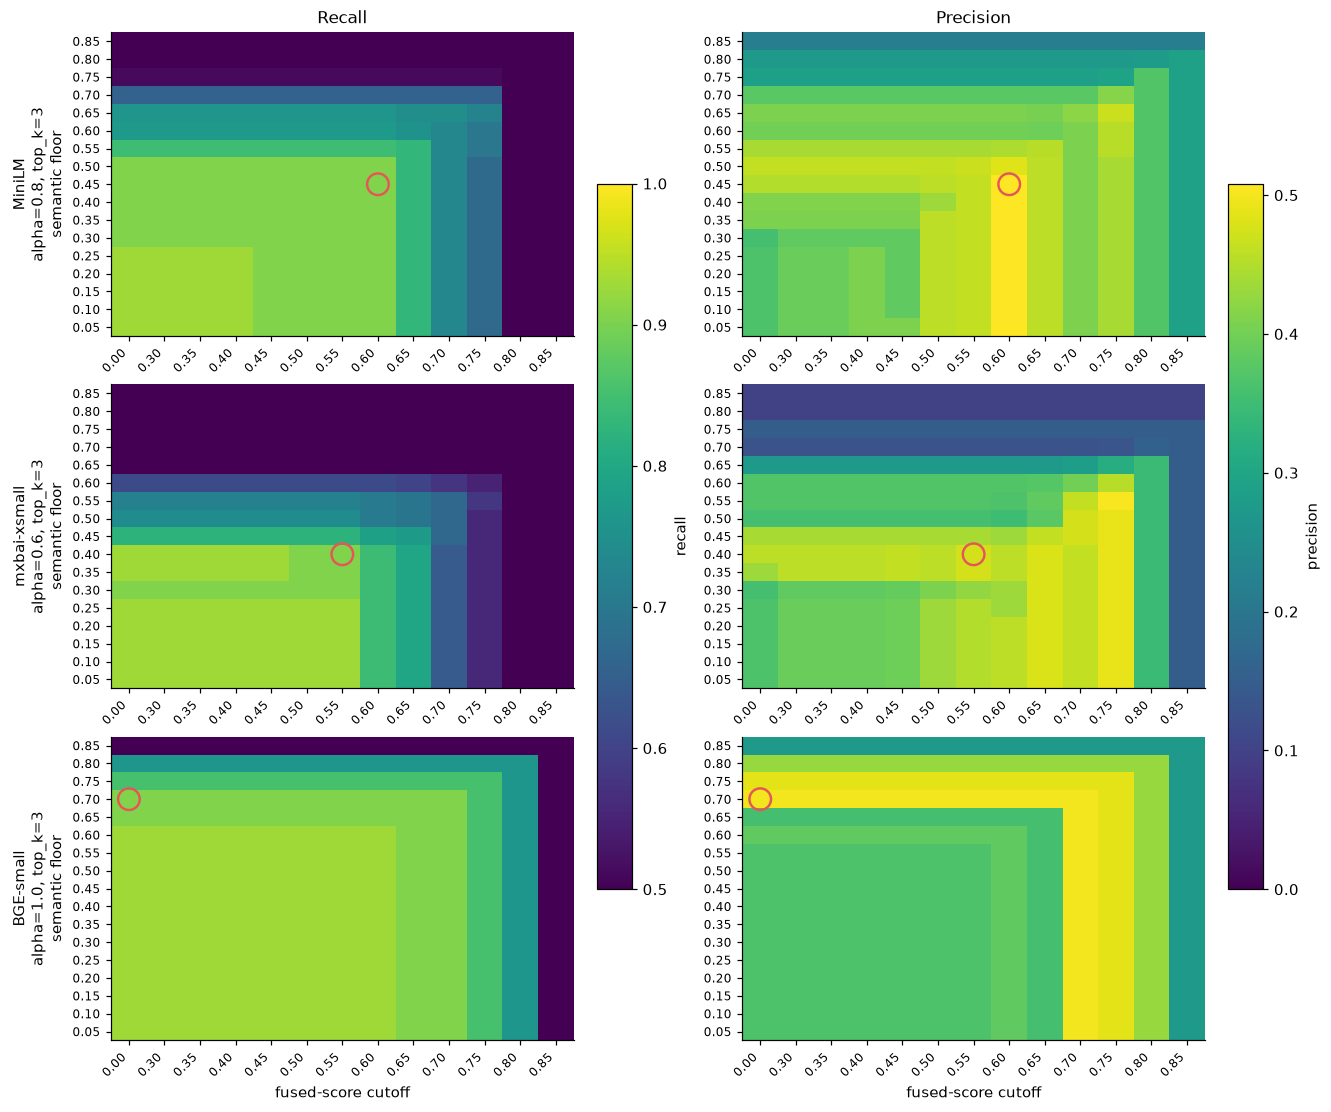

In [8]:
def slice_at(label, alpha, top_k):
    subset = grid[
        (grid.model == label)
        & np.isclose(grid.alpha, alpha)
        & (grid.top_k == int(top_k))
    ]
    return subset


def mark_cell(ax, pivot, floor, cutoff):
    ys = list(pivot.index)
    xs = list(pivot.columns)
    y = min(range(len(ys)), key=lambda i: abs(float(ys[i]) - float(floor)))
    x = min(range(len(xs)), key=lambda i: abs(float(xs[i]) - float(cutoff)))
    ax.scatter(
        [x], [y], s=200, facecolors="none", edgecolors="#E45756",
        linewidths=1.6, zorder=5,
    )


slices = {}
for _, row in operating.iterrows():
    slices[row["model"]] = slice_at(row["model"], row["alpha"], row["top_k"])

shown = pd.concat(slices.values(), ignore_index=True)
color_limits = {
    "recall": (0.5, 1.0),
    "precision": (0.0, max(0.01, float(shown["precision"].max()))),
}
fig, axes = plt.subplots(len(MODEL_ORDER), 2, figsize=(12, 10), constrained_layout=True)
images = [None, None]
for i, label in enumerate(MODEL_ORDER):
    row = operating[operating.model == label].iloc[0]
    subset = slices[label]
    for j, metric in enumerate(["recall", "precision"]):
        ax = axes[i, j]
        pivot = (
            subset.pivot(index="semantic_floor", columns="cutoff", values=metric)
            .sort_index(ascending=False)
        )
        image = ax.imshow(
            pivot.values,
            aspect="auto",
            vmin=color_limits[metric][0],
            vmax=color_limits[metric][1],
            cmap="viridis",
        )
        images[j] = image
        ax.set_xticks(range(len(pivot.columns)))
        ax.set_xticklabels([f"{value:.2f}" for value in pivot.columns], rotation=45, ha="right", fontsize=8)
        ax.set_yticks(range(len(pivot.index)))
        ax.set_yticklabels([f"{value:.2f}" for value in pivot.index], fontsize=8)
        mark_cell(ax, pivot, row["semantic_floor"], row["cutoff"])
        if i == 0:
            ax.set_title(metric.capitalize())
        if i == len(MODEL_ORDER) - 1:
            ax.set_xlabel("fused-score cutoff")
    axes[i, 0].set_ylabel(
        f"{label}\nalpha={row['alpha']:.1f}, top_k={int(row['top_k'])}\nsemantic floor"
    )
fig.colorbar(images[0], ax=axes[:, 0], shrink=0.7, label="recall")
fig.colorbar(images[1], ax=axes[:, 1], shrink=0.7, label="precision")
plt.show()


## Moving one knob

Each panel changes one parameter of the recommendation and holds the other three fixed. The dashed line is the chosen value. A flat line means the neighbors score the same thing. A slope means that knob is carrying the metric.


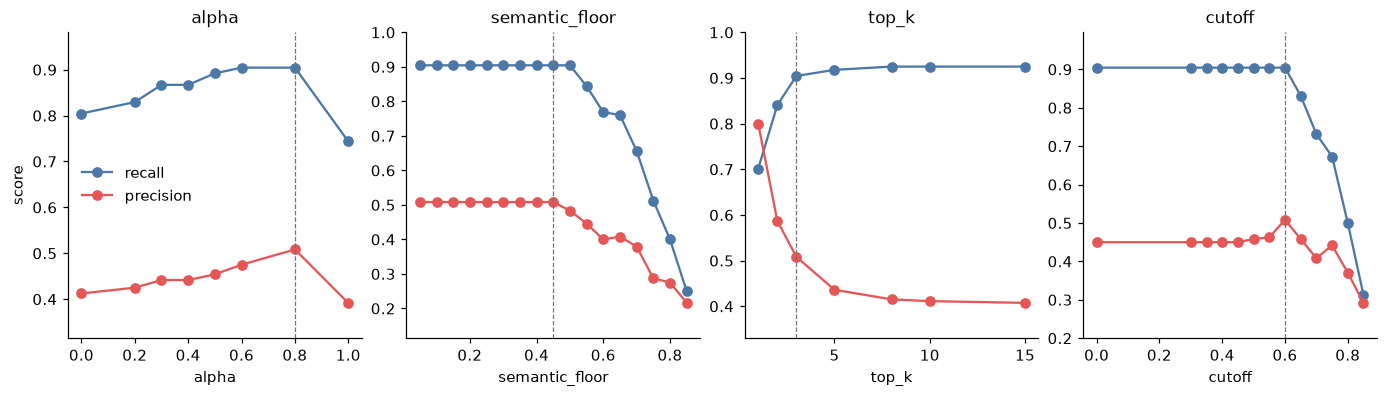

In [9]:
KNOBS = ["alpha", "semantic_floor", "top_k", "cutoff"]
held = grid[grid.model == recommended["model"]]
fig, axes = plt.subplots(1, 4, figsize=(12.5, 3.5), constrained_layout=True)
for ax, knob in zip(axes, KNOBS):
    sl = held
    for other in KNOBS:
        if other == knob:
            continue
        if other == "top_k":
            sl = sl[sl["top_k"] == int(recommended["top_k"])]
        else:
            sl = sl[np.isclose(sl[other], recommended[other])]
    sl = sl.sort_values(knob)
    ax.plot(sl[knob], sl["recall"], marker="o", color="#4C78A8", label="recall")
    ax.plot(sl[knob], sl["precision"], marker="o", color="#E45756", label="precision")
    ax.axvline(recommended[knob], color="0.45", lw=0.8, ls="--")
    lo = min(sl["recall"].min(), sl["precision"].min())
    hi = max(sl["recall"].max(), sl["precision"].max())
    pad = max(0.02, (hi - lo) * 0.15)
    ax.set_ylim(max(0, lo - pad), min(1, hi + pad))
    ax.set_xlabel(knob)
    ax.set_title(knob)
axes[0].legend(frameon=False)
axes[0].set_ylabel("score")
plt.show()


## Where it lands

Recall and precision by `query_type`, for today's MiniLM default and for the recommendation. On a no-match query, recall stays at 1 whether or not anything is returned. Precision is 1 only when the list is empty.


,n,recall_current,recall_recommended,precision_current,precision_recommended,recall_delta,precision_delta
exact,8,1.000,1.000,0.174,0.354,0.000,0.180
abbreviation,8,0.750,0.750,0.156,0.271,0.000,0.115
misspelled,8,1.000,1.000,0.157,0.479,0.000,0.322
partial,8,0.875,0.772,0.548,0.771,-0.103,0.223
word_order,4,1.000,1.000,0.126,0.333,0.000,0.208
no_match,4,1.000,1.000,0.250,1.000,0.000,0.750


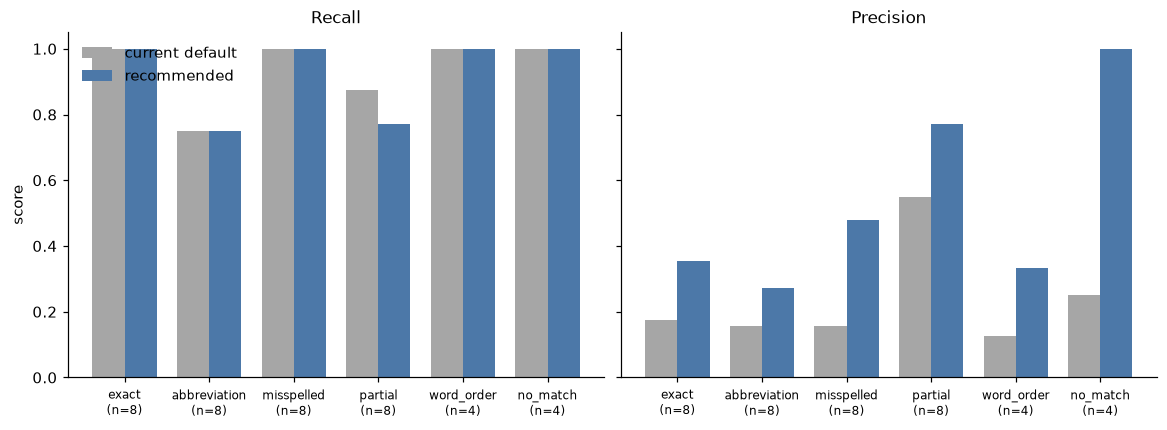

In [10]:
TYPE_ORDER = ["exact", "abbreviation", "misspelled", "partial", "word_order", "no_match"]


def by_type(spec):
    sem = encoders[spec["model"]]["sem"]
    rows = []
    for query_type, expected, sem_row, bm_row in zip(
        query_types, expected_lists, sem, bm25_matrix
    ):
        kept = kept_ids(
            sem_row, bm_row,
            spec["alpha"], spec["semantic_floor"], int(spec["top_k"]), spec["cutoff"],
        )
        precision, recall, f1, rr, ap = query_scores(kept, expected)
        rows.append({"query_type": query_type, "recall": recall, "precision": precision})
    return pd.DataFrame(rows)


def spec_of(row):
    return {
        "model": row["model"],
        "alpha": float(row["alpha"]),
        "semantic_floor": float(row["semantic_floor"]),
        "top_k": int(row["top_k"]),
        "cutoff": float(row["cutoff"]),
    }


current_by_type = by_type(CURRENT).groupby("query_type").mean()
recommended_by_type = by_type(spec_of(recommended)).groupby("query_type").mean()
counts = pd.Series(query_types).value_counts()
comparison = pd.DataFrame({
    "n": [int(counts[query_type]) for query_type in TYPE_ORDER],
    "recall_current": [current_by_type.loc[query_type, "recall"] for query_type in TYPE_ORDER],
    "recall_recommended": [recommended_by_type.loc[query_type, "recall"] for query_type in TYPE_ORDER],
    "precision_current": [current_by_type.loc[query_type, "precision"] for query_type in TYPE_ORDER],
    "precision_recommended": [recommended_by_type.loc[query_type, "precision"] for query_type in TYPE_ORDER],
}, index=TYPE_ORDER)
comparison["recall_delta"] = comparison["recall_recommended"] - comparison["recall_current"]
comparison["precision_delta"] = comparison["precision_recommended"] - comparison["precision_current"]
display(comparison.round(3))

fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.8), sharey=True, constrained_layout=True)
x = np.arange(len(TYPE_ORDER))
width = 0.38
tick_labels = [f"{query_type}\n(n={int(counts[query_type])})" for query_type in TYPE_ORDER]
for ax, metric in zip(axes, ["recall", "precision"]):
    ax.bar(
        x - width / 2, comparison[f"{metric}_current"], width,
        color="0.65", label="current default",
    )
    ax.bar(
        x + width / 2, comparison[f"{metric}_recommended"], width,
        color=COLORS[recommended["model"]], label="recommended",
    )
    ax.set_xticks(x)
    ax.set_xticklabels(tick_labels, fontsize=8)
    ax.set_ylim(0, 1.05)
    ax.set_title(metric.capitalize())
axes[0].legend(frameon=False)
axes[0].set_ylabel("score")
plt.show()


## Recommendation

The paragraph is computed from the grid, so re-running the notebook rewrites it. The bar is the median query time. The line runs out to the 95th percentile.


,role,model,alpha,semantic_floor,top_k,cutoff,recall,precision,mean_results,f1,mrr,latency_median_ms,latency_p95_ms
0,operating point,MiniLM,0.8,0.45,3,0.60,0.9045,0.5083,2.33,0.6056,0.8426,32.8,151.1
1,operating point,mxbai-xsmall,0.6,0.40,3,0.55,0.9045,0.4750,2.42,0.5723,0.8287,32.1,164.3
2,operating point,BGE-small,1.0,0.70,3,0.00,0.9045,0.5000,2.48,0.5973,0.8611,55.4,62.5
3,current MiniLM default,MiniLM,0.5,0.30,10,0.50,0.9250,0.2446,6.42,0.3351,0.8333,32.8,151.1


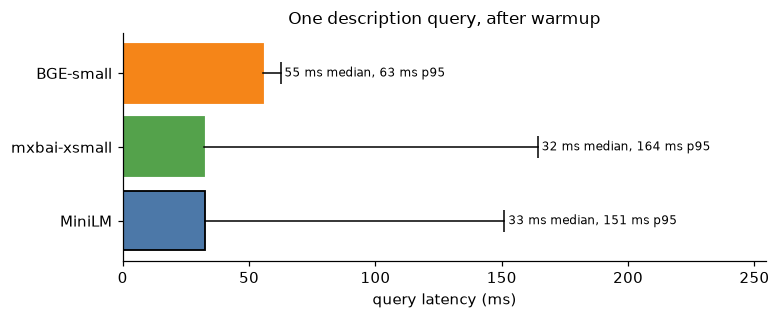

Use MiniLM (all-MiniLM-L6-v2) with alpha=0.8, semantic_floor=0.45, top_k=3, fused cutoff=0.60.
On these 40 queries that scores recall 0.904, precision 0.508, 2.3 items per query, F1 0.606, MRR 0.843, MAP 0.815.
Median query latency is 32.8 ms (151.1 ms at the 95th percentile).
Against the highest-recall MiniLM configuration (9.7 items per query), recall changes by -0.071 and precision by +0.313.
Against today's MiniLM default, recall changes by -0.021 and precision by +0.264.
Partial queries, which expect several items, move recall by -0.103 and precision by +0.223. No-match precision moves from 0.25 to 1.00.
MiniLM has the best precision among the three operating points.
mxbai-xsmall at its own operating point: recall 0.904, precision 0.475, 2.4 items per query, 32.1 ms median.
BGE-small at its own operating point: recall 0.904, precision 0.500, 2.5 items per query, 55.4 ms median.
These settings are fit to this catalog and these 40 queries. Per query, the encoder is most of the wait;

In [11]:
points = operating.set_index("model").loc[MODEL_ORDER].reset_index()
baseline_row = baseline.to_dict()
baseline_row["role"] = "current MiniLM default"
summary = pd.concat(
    [
        points.assign(role="operating point"),
        pd.DataFrame([baseline_row]),
    ],
    ignore_index=True,
)
show_table(summary[["role"] + SHOW_COLS])

fig, ax = plt.subplots(figsize=(7.2, 3.0))
for i, label in enumerate(MODEL_ORDER):
    row = points[points.model == label].iloc[0]
    edge = "black" if label == recommended["model"] else COLORS[label]
    ax.barh(i, row.latency_median_ms, color=COLORS[label], edgecolor=edge, linewidth=1.2, zorder=2)
    ax.plot(
        [row.latency_median_ms, row.latency_p95_ms], [i, i],
        color="black", lw=1.0, zorder=3,
    )
    ax.plot(row.latency_p95_ms, i, marker="|", color="black", markersize=14, zorder=4)
    ax.text(
        row.latency_p95_ms + 1.5,
        i,
        f"{row.latency_median_ms:.0f} ms median, {row.latency_p95_ms:.0f} ms p95",
        va="center",
        fontsize=8,
    )
ax.set_yticks(range(len(MODEL_ORDER)))
ax.set_yticklabels(MODEL_ORDER)
ax.set_xlabel("query latency (ms)")
ax.set_title("One description query, after warmup")
ax.set_xlim(0, float(points.latency_p95_ms.max()) * 1.55)
fig.tight_layout()
plt.show()


def edge_notes(row):
    notes = []
    if row["semantic_floor"] == min(FLOORS):
        sem = encoders[row["model"]]["sem"]
        share = float((sem >= row["semantic_floor"]).mean())
        notes.append(
            f"semantic_floor is at the bottom of the grid ({min(FLOORS):.2f}), "
            f"and {share:.0%} of query-item scores already clear it"
        )
    if row["semantic_floor"] == max(FLOORS):
        notes.append(f"semantic_floor is at the top of the grid ({max(FLOORS):.2f})")
    if row["cutoff"] == max(CUTOFFS):
        notes.append(f"cutoff is at the top of the grid ({max(CUTOFFS):.2f})")
    if int(row["top_k"]) == min(TOP_KS):
        notes.append(f"top_k is at the bottom of the grid ({min(TOP_KS)})")
    if int(row["top_k"]) == max(TOP_KS):
        notes.append(f"top_k is at the top of the grid ({max(TOP_KS)})")
    if row["alpha"] == 0.0:
        notes.append("alpha is 0, so the fused score is rescaled BM25 inside the semantic gate")
    if row["alpha"] == 1.0:
        notes.append("alpha is 1, so the fused score is the cosine")
    return notes


lines = [
    (
        f"Use {recommended['model']} ({encoders[recommended['model']]['model_name']}) "
        f"with alpha={recommended['alpha']:.1f}, semantic_floor={recommended['semantic_floor']:.2f}, "
        f"top_k={int(recommended['top_k'])}, fused cutoff={recommended['cutoff']:.2f}."
    ),
    (
        f"On these {len(query_texts)} queries that scores recall {recommended['recall']:.3f}, "
        f"precision {recommended['precision']:.3f}, {recommended['mean_results']:.1f} items per query, "
        f"F1 {recommended['f1']:.3f}, MRR {recommended['mrr']:.3f}, "
        f"MAP {recommended['average_precision']:.3f}."
    ),
    (
        f"Median query latency is {recommended['latency_median_ms']:.1f} ms "
        f"({recommended['latency_p95_ms']:.1f} ms at the 95th percentile)."
    ),
    (
        f"Against the highest-recall {recommended['model']} configuration "
        f"({recommended_anchor['mean_results']:.1f} items per query), recall changes by "
        f"{recommended['recall'] - recommended_anchor['recall']:+.3f} and precision by "
        f"{recommended['precision'] - recommended_anchor['precision']:+.3f}."
    ),
    (
        f"Against today's MiniLM default, recall changes by "
        f"{recommended['recall'] - baseline['recall']:+.3f} and precision by "
        f"{recommended['precision'] - baseline['precision']:+.3f}."
    ),
]
partial = comparison.loc["partial"]
no_match = comparison.loc["no_match"]
lines.append(
    f"Partial queries, which expect several items, move recall by {partial['recall_delta']:+.3f} "
    f"and precision by {partial['precision_delta']:+.3f}. "
    f"No-match precision moves from {no_match['precision_current']:.2f} to {no_match['precision_recommended']:.2f}."
)
if recommended["model"] == leader["model"]:
    lines.append(
        f"{recommended['model']} has the best precision among the three operating points."
    )
else:
    lines.append(
        f"{leader['model']} has the best precision. {recommended['model']} is within "
        f"{FASTER_MODEL_TOLERANCE:.2f} on precision and recall and at least "
        f"{FASTER_MODEL_MS:.0f} ms faster, so it is the one to use."
    )
for _, row in points.iterrows():
    if row["model"] == recommended["model"]:
        continue
    lines.append(
        f"{row['model']} at its own operating point: recall {row['recall']:.3f}, "
        f"precision {row['precision']:.3f}, {row['mean_results']:.1f} items per query, "
        f"{row['latency_median_ms']:.1f} ms median."
    )
for note in edge_notes(recommended):
    lines.append(note.capitalize() + ".")
lines.append(
    "These settings are fit to this catalog and these 40 queries. "
    "Per query, the encoder is most of the wait; the latency ordering of the three models is the part that still holds on a larger catalog. "
    "The floor and the cutoff should be fit again if the catalog changes, because both depend on how close the neighboring descriptions are."
)
print("\n".join(lines))
